In [15]:
import logging
import random

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

from vasae.data.dataset import GPT2LayerActivations



logging.basicConfig(
    format="[%(levelname)s] %(asctime)s %(message)s",
    level=logging.INFO,
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger()

In [16]:
from pathlib import Path
from vasae.configs.data import DataConfig

data_cfg = DataConfig(
    train_batchsize=128,
    valid_batchsize=128,
    test_batchsize=128,
    use_centralize=True,
    data_dir = Path(
        r"/scratch/b5bq/pu22650.b5bq/activations_gpt2_Geralt-Targaryen_openwebtext2"
    ),
    layer_name = "transformer.h.0"
)


In [17]:
class CFG:
    seed = 42

    meta_path = "/scratch/b5bq/pu22650.b5bq/activations_gpt2_Geralt-Targaryen_openwebtext2/meta.json"
    layer_name = "transformer.h.5"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model_name = "gpt2"
    save_dir = "out"


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [18]:

set_seed(42)

dataset = GPT2LayerActivations(data_cfg)


# box
不同样本同一层不同位置的box
- 中间近似正太，但重尾。外点只是因为不满足箱型图规则。
- activations大部分样本每个维度还是比较理想的，seq0确实可能大量数据更集中一些，但并不应该影响学习，数据量足够大，真的就是有几个噪声，应该也不影响。

In [ ]:
num_dims = 10    
fig, axs = plt.subplots(nrows=num_dims,ncols=1,figsize=(3.5, 25),layout="constrained")
for d in range(num_dims):
    x = dataset[0:-1][:,:,d]
    axs[d].boxplot(x, showfliers=True)
plt.title("layer 5 activations seq pos from 0 to 8 at dim 0")
plt.xlabel("Seq_i")
plt.ylabel("Value")
plt.show()

# center后
明显mean就是0了，应该会更好学

In [ ]:
dataset_c = GPT2LayerActivations(args.meta_path, args.layer_name,use_centralize=True)

In [ ]:
num_dims = 10    
fig, axs = plt.subplots(nrows=num_dims,ncols=1,figsize=(3.5, 25),layout="constrained")
for d in range(num_dims):
    x = dataset_c[0:-1][:,:,d]
    axs[d].boxplot(x, showfliers=True)
plt.xlabel("Seq_i")
plt.ylabel("Value")
plt.show()

# (seq,dim,mean)

In [ ]:
x = dataset[0:-1].mean(dim=0)
xmin = x.min().item()
xmax = x.max().item()
print(xmin, xmax)

In [ ]:
plt.boxplot(x.flatten(), showfliers=False)

In [ ]:
x = dataset[0:-1].mean(dim=0)
xmin = x.min().item()
xmax = x.max().item()



plt.figure()
plt.imshow(
    x.numpy(),
    aspect='auto',
    norm=SymLogNorm(
        linthresh=1,   # -20~20 线性
        linscale=5.0,   # 线性区在颜色轴上占更大比例
        vmin=xmin,
        vmax=xmax
    )
)
plt.xlabel("Dim (768)")
plt.ylabel("Seq (64)")
plt.colorbar()
plt.show()

In [ ]:
x = dataset[0:-1].std(dim=0)
xmin = x.min().item()
xmax = x.max().item()
print(xmin, xmax)

In [ ]:
plt.boxplot(x.flatten(), showfliers=False)

In [ ]:



plt.figure()
plt.imshow(
    x.numpy(),
    aspect='auto',

)
plt.xlabel("Dim (768)")
plt.ylabel("Seq (64)")
plt.colorbar()
plt.show()

In [ ]:


# 假设已有 tensor x，形状 [64, 768]
# x = your_tensor
x = dataset[0]

xmin = x.min().item()
xmax = x.max().item()

plt.figure()
plt.imshow(
    x.cpu().numpy(),
    aspect='auto',
    vmin=-2,
    vmax=2
)
plt.colorbar()
plt.xlabel("Dim (768)")
plt.ylabel("Seq (64)")
plt.show()

print("min:", xmin, "max:", xmax)

x.flatten().topk(10)

In [ ]:
x.std()

In [ ]:
import torch
x = dataset[0]
# x: [batch, seq, hidden] 或任意 shape
abs_x = x.flatten()

p99   = torch.quantile(abs_x, 0.9)
p999  = torch.quantile(abs_x, 0.999)

print(p99.item(), p999.item())

In [ ]:
import torch
x = torch.tensor([-1,2,3], dtype=torch.float32)
torch.quantile(x, 0.5)

# heatmap

In [ ]:
from matplotlib.colors import SymLogNorm

x = dataset[0]

xmin = x.min().item()
xmax = x.max().item()


plt.figure()
plt.imshow(
    x.numpy(),
    aspect='auto',
    norm=SymLogNorm(
        linthresh=4,   # -20~20 线性
        linscale=5.0,   # 线性区在颜色轴上占更大比例
        vmin=xmin,
        vmax=xmax
    )
)
plt.colorbar()
plt.show()

# centralized后箱型图

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

class AsymPieceLogNorm(Normalize):
    """
    [-5, 4] 线性放大；左侧/右侧对数压缩
    输出严格落在 [0,1]，colorbar 不会乱
    """
    def __init__(self, vmin, vmax, lin_min, lin_max,
                 lin_frac=0.6, eps=1e-6):
        super().__init__(vmin=vmin, vmax=vmax, clip=True)
        self.lin_min = lin_min
        self.lin_max = lin_max
        self.eps = eps
        self.left_frac = (1 - lin_frac) / 2
        self.mid_frac  = lin_frac
        self.right_frac = (1 - lin_frac) / 2

    def __call__(self, value, clip=None):
        v = np.asarray(value, dtype=float)
        v = np.clip(v, self.vmin, self.vmax)

        out = np.empty_like(v, dtype=float)

        L = self.left_frac
        M = self.mid_frac
        # R = self.right_frac  # 其实= L

        # 左侧：vmin -> 0, lin_min -> L（对数压缩）
        mask_l = v < self.lin_min
        if np.any(mask_l):
            ratio = (v[mask_l] - self.vmin) / (self.lin_min - self.vmin)
            ratio = np.clip(ratio, self.eps, 1.0)
            t = np.log10(ratio) / np.log10(self.eps)   # eps->1, 1->0
            out[mask_l] = L * (1 - t)                  # vmin≈0, lin_min=L

        # 中间：lin_min -> L, lin_max -> L+M（线性放大）
        mask_m = (v >= self.lin_min) & (v <= self.lin_max)
        out[mask_m] = L + M * (v[mask_m] - self.lin_min) / (self.lin_max - self.lin_min)

        # 右侧：lin_max -> L+M, vmax -> 1（对数压缩）
        mask_r = v > self.lin_max
        if np.any(mask_r):
            ratio = (v[mask_r] - self.lin_max) / (self.vmax - self.lin_max)
            ratio = np.clip(ratio, self.eps, 1.0)
            t = np.log10(ratio) / np.log10(self.eps)   # eps->1, 1->0
            out[mask_r] = (L + M) + L * (1 - t)        # lin_max=L+M, vmax=1

        return out

# ---------------- 用法 ----------------
# x: torch.Tensor [64,768]
# x = your_tensor.cpu().numpy()
x = np.random.randn(64, 768) * 20
x = np.clip(x, -250, 2000)

norm = AsymPieceLogNorm(vmin=-250, vmax=2000, lin_min=-5, lin_max=4, lin_frac=0.3)

fig, ax = plt.subplots()
im = ax.imshow(x, aspect="auto", norm=norm)

# 关键：手动指定刻度，避免自动挤爆
ticks = [-250, -60, -5, 0, 4, 10, 100, 500, 2000]
cbar = fig.colorbar(im, ax=ax, ticks=ticks)
cbar.ax.set_yticklabels([str(t) for t in ticks])

plt.show()

# 可视化范数分布

可视化activations范数的histogram

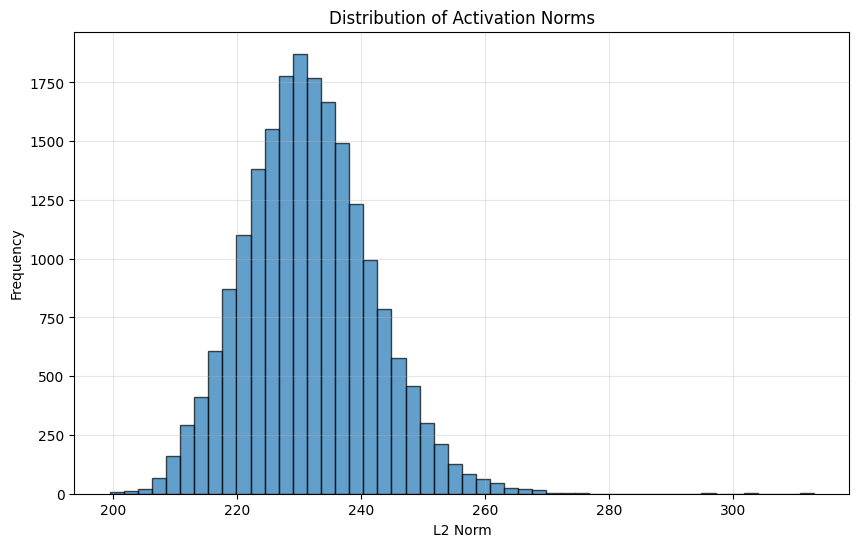

Mean norm: 231.4975
Std norm: 10.1768
Min norm: 199.4257
Max norm: 313.0245


In [11]:
# Compute the norm of activations for each sample
norms = []
for i in range(len(dataset)):
    x = dataset[i]['activations']  # shape: [seq, dim]
    norm = torch.norm(x, p=2).item()
    norms.append(norm)

norms = np.array(norms)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(norms, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel("L2 Norm")
plt.ylabel("Frequency")
plt.title("Distribution of Activation Norms")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean norm: {norms.mean():.4f}")
print(f"Std norm: {norms.std():.4f}")
print(f"Min norm: {norms.min():.4f}")
print(f"Max norm: {norms.max():.4f}")

In [21]:
# Compare activations across all 12 layers
layers = [f"transformer.h.{i}" for i in range(12)]
norms_by_layer = {}

for layer in layers:
    data_cfg.layer_name = layer
    dataset_layer = GPT2LayerActivations(data_cfg)
    
    layer_norms = []
    for i in range(len(dataset_layer)):
        x = dataset_layer[i]['activations']
        norm = torch.norm(x, p=2).item()
        layer_norms.append(norm)
    
    norms_by_layer[layer] = np.array(layer_norms)


# Print statistics for each layer
print("\nStatistics by layer:")
for layer in layers:
    norms = norms_by_layer[layer]
    print(f"{layer}: Mean={norms.mean():.4f}, Std={norms.std():.4f}, Min={norms.min():.4f}, Max={norms.max():.4f}")


Statistics by layer:
transformer.h.0: Mean=231.4975, Std=10.1768, Min=199.4257, Max=313.0245
transformer.h.1: Mean=271.3159, Std=10.6692, Min=235.7852, Max=368.6427
transformer.h.2: Mean=311.9425, Std=11.8178, Min=274.2538, Max=424.1926
transformer.h.3: Mean=360.1869, Std=13.3473, Min=317.9090, Max=488.3744
transformer.h.4: Mean=404.4873, Std=15.2270, Min=358.6983, Max=555.2319
transformer.h.5: Mean=456.0864, Std=17.8551, Min=408.3227, Max=643.8516
transformer.h.6: Mean=518.1648, Std=21.0753, Min=463.2730, Max=736.2073
transformer.h.7: Mean=600.4013, Std=24.6255, Min=540.6570, Max=851.7864
transformer.h.8: Mean=706.0354, Std=27.0239, Min=643.7325, Max=949.3453
transformer.h.9: Mean=856.1537, Std=31.8321, Min=768.2794, Max=1113.2874
transformer.h.10: Mean=1074.4917, Std=46.2895, Min=940.0009, Max=1526.3745
transformer.h.11: Mean=1801.3648, Std=257.3473, Min=1304.7931, Max=3692.0405


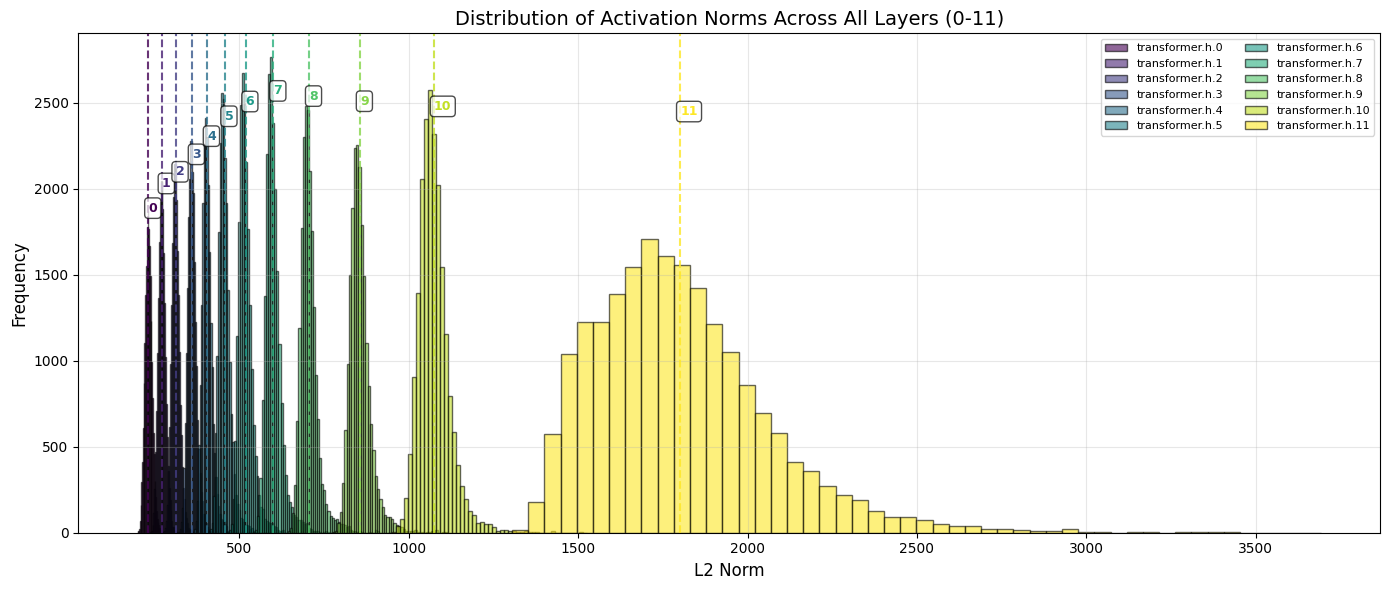

In [20]:
# Create a clearer visualization with gradient colors and layer labels at mean positions
fig, ax = plt.subplots(figsize=(14, 6))

# Create gradient colors from light to dark
colors_gradient = plt.cm.viridis(np.linspace(0, 1, 12))

for idx, layer in enumerate(layers):
    norms = norms_by_layer[layer]
    ax.hist(norms, bins=50, alpha=0.6, label=layer, color=colors_gradient[idx], edgecolor='black')
    
    # Add layer number label at the mean position
    mean_norm = norms.mean()
    ax.axvline(mean_norm, color=colors_gradient[idx], linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(mean_norm, ax.get_ylim()[1] * 0.95 - idx * 30, str(idx), 
            fontsize=9, color=colors_gradient[idx], fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel("L2 Norm", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of Activation Norms Across All Layers (0-11)", fontsize=14)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
/local/user/1483802117/ipykernel_176347/2670911001.py:32: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(x_data, y_exp, '--', linewidth=2, label='$y = 10.27\exp(0.45x) + 306.30$')


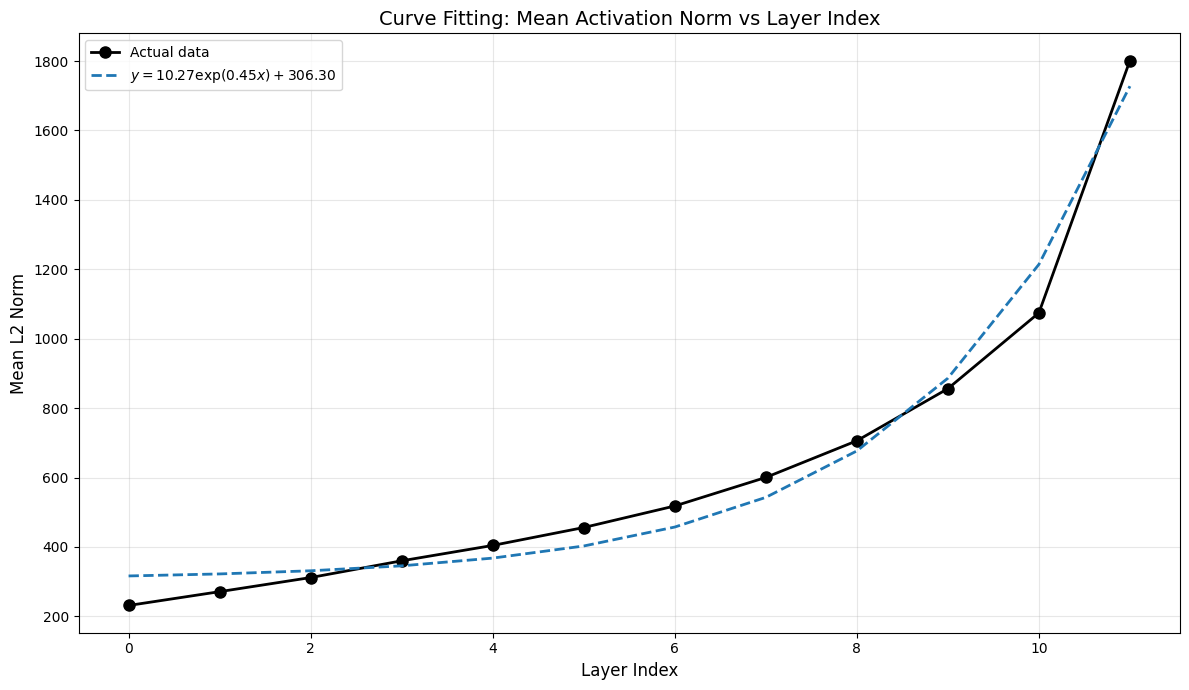

Fitting Results:
Exponential: y = 10.2704*exp(0.4482*x) + 306.2989


In [26]:
from scipy.optimize import curve_fit

# Extract mean norms for each layer
layer_indices = list(range(len(layers)))
mean_norms = [norms_by_layer[layer].mean() for layer in layers]

# Try fitting different functions to the mean_norms curve
x_data = np.array(layer_indices, dtype=float)
y_data = np.array(mean_norms, dtype=float)



# 3. Exponential fit
def exp_func(x, a, b, c):
    return a * np.exp(b * x) + c

try:
    popt_exp, _ = curve_fit(exp_func, x_data, y_data, p0=[1, 0.1, 0], maxfev=5000)
    y_exp = exp_func(x_data, *popt_exp)
except:
    y_exp = None
    popt_exp = None



# Plot all fits
plt.figure(figsize=(12, 7))
plt.plot(x_data, y_data, 'o-', linewidth=2, markersize=8, label='Actual data', color='black')


if y_exp is not None:
    plt.plot(x_data, y_exp, '--', linewidth=2, label='$y = 10.27\exp(0.45x) + 306.30$')


plt.xlabel("Layer Index", fontsize=12)
plt.ylabel("Mean L2 Norm", fontsize=12)
plt.title("Curve Fitting: Mean Activation Norm vs Layer Index", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print fitting results
print("Fitting Results:")

if popt_exp is not None:
    print(f"Exponential: y = {popt_exp[0]:.4f}*exp({popt_exp[1]:.4f}*x) + {popt_exp[2]:.4f}")
